<a href="https://www.kaggle.com/code/felipeidarraga/tfagents-pendul?scriptVersionId=252339742" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

#  Estrategia de Solución
1. Definir el entorno
2. Diseñar el agente
Puedes usar algoritmos actor-critic continuos como:
- DDPG (Deep Deterministic Policy Gradient)
- TD3 (Twin Delayed DDPG)
- SAC (Soft Actor-Critic) ✅ (recomendado)
3. Entrenar
Entrena usando el entorno.
Ajusta hiperparámetros para lograr estabilidad y buen desempeño.
4. Evaluar desempeño
Verifica que el péndulo esté en vertical y sin exceso de torque.
Graficar recompensa vs episodio, torque aplicado, etc.

# Prompt 1
Quiero comenzar un ejercicio de aprendizaje por refuerzo continuo utilizando el entorno Pendulum-v1 de Gymnasium junto con la librería TF-Agents. Para ello, necesito que primero instales las dependencias necesarias, incluyendo tf-agents[reverb] y gymnasium[classic-control]. Luego, importa todas las librerías relevantes para trabajar con TF-Agents, TensorFlow, NumPy, Matplotlib y Gym. A continuación, carga el entorno Pendulum-v1 usando suite_gym de TF-Agents para obtener dos entornos: uno para entrenamiento y otro para evaluación, y conviértelos a objetos TFPyEnvironment. También quiero que imprimas la especificación de observaciones y acciones del entorno de entrenamiento para verificar que todo está funcionando correctamente. Además, crea un entorno adicional usando Gymnasium (con render_mode="rgb_array") solo para visualización, y define una función llamada plot_environment() que renderice una imagen del entorno y la muestre usando Matplotlib. Por favor, organiza el código resultante en celdas, como si fuera a ejecutarse en un entorno tipo Jupyter Notebook o Kaggle.

# Instalación de dependencias

In [2]:
!pip install -q tf-agents[reverb]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.4/624.4 kB 9.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.3/475.3 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 90.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 101.4 MB/s eta 0:00:00
   ━━

In [3]:
import tf_agents
print("TF-Agents version:", tf_agents.__version__)

2025-07-24 23:49:18.741042: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-24 23:49:18.741110: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-24 23:49:18.743251: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/gymnasium/envs/registration.py:596: UserWarning: WARN: plugin: shimmy.registration:register_gymnasium_envs raised Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/gymnasium/envs/registration.py", line 594, in load_plugin_envs
    fn()
  File "/usr/local/lib/python3.11/dist-packages/shimmy/r

TF-Agents version: 0.19.0


# Importación de librerías y configuración del entorno

In [4]:
# IMPORTACIONES
import gym                             # Para entrenamiento con TF-Agents
import gymnasium as gym_vis           # Solo para visualización con render_mode
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tf_agents.environments import suite_gym
from tf_agents.environments import tf_py_environment


# CARGAR ENTORNOS PARA TF-AGENTS USANDO suite_gym
env_name = "Pendulum-v1"

# suite_gym carga el entorno clásico Gym automáticamente envuelto
train_py_env = suite_gym.load(env_name)
eval_py_env  = suite_gym.load(env_name)

# Convertir a entornos TensorFlow (TFPyEnvironment)
train_env = tf_py_environment.TFPyEnvironment(train_py_env)
eval_env  = tf_py_environment.TFPyEnvironment(eval_py_env)

# VERIFICACIÓN 
print("Train env:", train_env)
print("Observation spec:", train_env.observation_spec())
print("Action spec:", train_env.action_spec())

Train env: <tf_agents.environments.tf_py_environment.TFPyEnvironment object at 0x7b1fbb79cf90>
Observation spec: BoundedTensorSpec(shape=(3,), dtype=tf.float32, name='observation', minimum=array([-1., -1., -8.], dtype=float32), maximum=array([1., 1., 8.], dtype=float32))
Action spec: BoundedTensorSpec(shape=(1,), dtype=tf.float32, name='action', minimum=array(-2., dtype=float32), maximum=array(2., dtype=float32))


# Visualización del entorno con Gymnasium

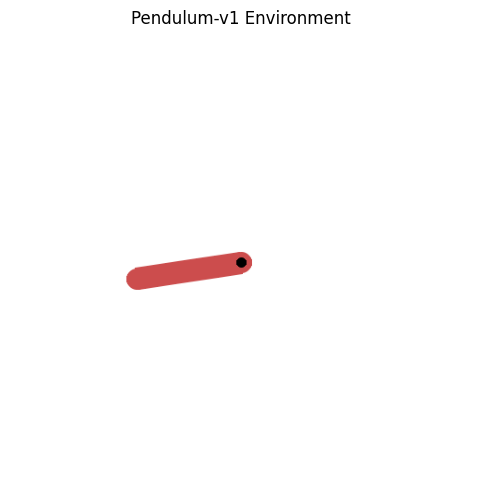

In [5]:
# VISUALIZACIÓN CON GYMNASIUM (NO USADO EN ENTRENAMIENTO)
env = gym_vis.make("Pendulum-v1", render_mode="rgb_array")
obs, _ = env.reset(seed=42)

def plot_environment(env, figsize=(6, 6)):
    img = env.render()  # Devuelve imagen RGB
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Pendulum-v1 Environment")
    plt.show()

# Mostrar una imagen del entorno
plot_environment(env)


# Prompt 2
Define los hiperparámetros necesarios para entrenar un agente DDPG (DdpgAgent) en el entorno Pendulum-v1 usando TF-Agents. Incluye los parámetros globales de entrenamiento como número de iteraciones, pasos de recolección inicial, tamaño del replay buffer, batch size, etc. También incluye los hiperparámetros específicos del agente DDPG: tamaño de las capas ocultas para el actor y el crítico, tasas de aprendizaje, el parámetro gamma (descuento de recompensa), el parámetro tau (actualización suave de redes objetivo), y los parámetros del proceso de exploración Ornstein-Uhlenbeck (ou_stddev, ou_damping). Organiza el código como una celda de notebook clara y estructurada.

# Definición de hiperparámetros del agente DDPG

In [6]:
# Hiperparámetros globales de entrenamiento
num_iterations = 50_000               # 🔽 Reducido para entrenar en ~1h
initial_collect_steps = 1000
collect_steps_per_iteration = 1
replay_buffer_capacity = 100_000

batch_size = 64
log_interval = 200
eval_interval = 1000
num_eval_episodes = 10

# Hiperparámetros de redes y optimización
actor_fc_layers = (128, 128)          # 🔽 Más ligeras pero efectivas para Pendulum
critic_fc_layers = (128, 128)

actor_lr = 3e-4
critic_lr = 3e-4

gamma = 0.99
tau = 0.005

# Exploración (ruido Ornstein-Uhlenbeck)
ou_stddev = 0.2
ou_damping = 0.15



# Prompt 3
Define las redes neuronales necesarias para un agente DDPG (DdpgAgent) en el entorno Pendulum-v1 usando TF-Agents. Crea una red actor determinista que reciba la observación y devuelva una acción continua, utilizando la clase ActorNetwork desde tf_agents.agents.ddpg.actor_network. Luego, define una red crítica que reciba como entrada una tupla (observación, acción) y devuelva el valor estimado Q, utilizando la clase CriticNetwork desde tf_agents.agents.ddpg.critic_network. Usa los tamaños de capa definidos en los hiperparámetros (actor_fc_layers y critic_fc_layers). Al final, imprime una verificación que confirme que las redes fueron creadas correctamente.

# Definición de redes actor y crítico para DDPG

In [7]:
from tf_agents.agents.ddpg.actor_network import ActorNetwork
from tf_agents.agents.ddpg.critic_network import CriticNetwork

# Extraer especificaciones del entorno
observation_spec = train_env.observation_spec()
action_spec = train_env.action_spec()

# Red del actor: salida determinista (acción continua)
actor_net = ActorNetwork(
    input_tensor_spec=observation_spec,
    output_tensor_spec=action_spec,
    fc_layer_params=actor_fc_layers
)

# Red del crítico: Q(s, a)
critic_net = CriticNetwork(
    input_tensor_spec=(observation_spec, action_spec),
    observation_fc_layer_params=None,
    action_fc_layer_params=None,
    joint_fc_layer_params=critic_fc_layers
)

# Verificación
print("✅ Redes actor y crítico (DDPG) definidas correctamente")
print("actor_net:", actor_net)
print("critic_net:", critic_net)


✅ Redes actor y crítico (DDPG) definidas correctamente
actor_net: <tf_agents.agents.ddpg.actor_network.ActorNetwork object at 0x7b1fbb77ef90>
critic_net: <tf_agents.agents.ddpg.critic_network.CriticNetwork object at 0x7b1fba550dd0>


# Prompt 4
Crea un agente DDPG (DdpgAgent) utilizando TF-Agents para el entorno Pendulum-v1. Usa las redes actor_net y critic_net previamente definidas, y configura el agente con los hiperparámetros correspondientes, como las tasas de aprendizaje para el actor y el crítico (actor_lr, critic_lr), el factor de descuento gamma, el parámetro de actualización suave tau, y los parámetros de ruido Ornstein-Uhlenbeck para la exploración (ou_stddev, ou_damping). Asegúrate de definir un contador de pasos train_step y llamar a agent.initialize(). Al final, imprime un mensaje de verificación para confirmar que el agente fue creado correctamente.

# Creación del agente DDPG

In [8]:
from tf_agents.agents.ddpg import ddpg_agent

# Contador de pasos de entrenamiento
train_step = tf.Variable(0)

# Optimizadores
actor_optimizer = tf.keras.optimizers.Adam(learning_rate=actor_lr)
critic_optimizer = tf.keras.optimizers.Adam(learning_rate=critic_lr)

# Crear agente DDPG
agent = ddpg_agent.DdpgAgent(
    time_step_spec=train_env.time_step_spec(),
    action_spec=train_env.action_spec(),
    actor_network=actor_net,
    critic_network=critic_net,
    actor_optimizer=actor_optimizer,
    critic_optimizer=critic_optimizer,
    ou_stddev=ou_stddev,
    ou_damping=ou_damping,
    target_update_tau=tau,
    target_update_period=1,
    gamma=gamma,
    reward_scale_factor=1.0,
    train_step_counter=train_step
)

# Inicializar variables internas
agent.initialize()

# Verificación
print("Agente DDPG creado e inicializado correctamente.")
print("Política de recolección:", agent.collect_policy)
print("Política para evaluación:", agent.policy)


Agente DDPG creado e inicializado correctamente.
Política de recolección: <tf_agents.policies.ou_noise_policy.OUNoisePolicy object at 0x7b1fba598dd0>
Política para evaluación: <tf_agents.policies.actor_policy.ActorPolicy object at 0x7b1fb9731990>


#  Prompt 5

Configura los componentes necesarios para que el agente DDPG recolecte experiencias del entorno. Usa la política de recolección del agente (agent.collect_policy) para interactuar con el entorno train_env. Crea un TFUniformReplayBuffer con las especificaciones de datos del agente, el batch_size del entorno y una capacidad máxima definida en los hiperparámetros. Luego, configura un DynamicStepDriver que recolecte transiciones paso a paso utilizando esa política, y almacene las experiencias directamente en el buffer. También puedes incluir una métrica opcional para contar episodios. Al final, imprime un mensaje de verificación que confirme que la política, el buffer y el driver fueron configurados correctamente.

# Configuración de política de recolección, replay buffer y driver

In [9]:
from tf_agents.replay_buffers import tf_uniform_replay_buffer
from tf_agents.drivers import dynamic_step_driver
from tf_agents.metrics import tf_metrics

# Política de recolección del agente (con ruido OU para exploración)
collect_policy = agent.collect_policy

# Replay Buffer
replay_buffer = tf_uniform_replay_buffer.TFUniformReplayBuffer(
    data_spec=agent.collect_data_spec,
    batch_size=train_env.batch_size,
    max_length=replay_buffer_capacity
)

# Métrica opcional
collect_step_counter = tf_metrics.NumberOfEpisodes()

# Driver para recolección de datos paso a paso
collect_driver = dynamic_step_driver.DynamicStepDriver(
    env=train_env,
    policy=collect_policy,
    observers=[replay_buffer.add_batch, collect_step_counter],
    num_steps=collect_steps_per_iteration
)

# Verificación
print("Política de recolección, replay buffer y driver configurados correctamente.")
print("Capacidad del buffer:", replay_buffer_capacity)
print("Especificación del buffer:", replay_buffer.data_spec)


Política de recolección, replay buffer y driver configurados correctamente.
Capacidad del buffer: 100000
Especificación del buffer: Trajectory(
{'step_type': TensorSpec(shape=(), dtype=tf.int32, name='step_type'),
 'observation': BoundedTensorSpec(shape=(3,), dtype=tf.float32, name='observation', minimum=array([-1., -1., -8.], dtype=float32), maximum=array([1., 1., 8.], dtype=float32)),
 'action': BoundedTensorSpec(shape=(1,), dtype=tf.float32, name='action', minimum=array(-2., dtype=float32), maximum=array(2., dtype=float32)),
 'policy_info': (),
 'next_step_type': TensorSpec(shape=(), dtype=tf.int32, name='step_type'),
 'reward': TensorSpec(shape=(), dtype=tf.float32, name='reward'),
 'discount': BoundedTensorSpec(shape=(), dtype=tf.float32, name='discount', minimum=array(0., dtype=float32), maximum=array(1., dtype=float32))})


# Prompt 6
Antes de entrenar al agente DDPG, recolecta una cantidad inicial de experiencias usando una política completamente aleatoria (RandomTFPolicy). Esta política actuará sobre el entorno train_env durante una cantidad de pasos definidos por initial_collect_steps. Para ello, configura un DynamicStepDriver con esta política aleatoria y el replay buffer como observador, para almacenar las transiciones recolectadas. Ejecuta el driver para llenar el buffer inicial. Al final, imprime un mensaje que confirme que la recolección inicial fue completada correctamente.

# Recolección inicial de experiencias


In [10]:

from tf_agents.policies.random_tf_policy import RandomTFPolicy

# Política completamente aleatoria
random_policy = RandomTFPolicy(train_env.time_step_spec(), train_env.action_spec())

# Driver para recolección inicial
initial_collect_driver = dynamic_step_driver.DynamicStepDriver(
    env=train_env,
    policy=random_policy,
    observers=[replay_buffer.add_batch],
    num_steps=initial_collect_steps
)

# Ejecutar recolección inicial
final_time_step, _ = initial_collect_driver.run()

# Verificación
print(f"Recolección inicial completada con {initial_collect_steps} pasos aleatorios.")


Recolección inicial completada con 1000 pasos aleatorios.


# Prompt 7
Crea un dataset a partir del replay buffer configurado previamente, para usarlo como fuente de experiencias durante el entrenamiento del agente DDPG. Usa el método as_dataset del buffer, especificando el batch_size y num_steps=2 para obtener transiciones completas (s, a, r, s′). Crea un iterador con iter(...) para obtener muestras del dataset. Luego, verifica el funcionamiento del dataset extrayendo un batch con next(iterator) y mostrando la forma de las observaciones, acciones y recompensas.

# Configuración del dataset para el entrenamiento

In [11]:
# Dataset desde el Replay Buffer
dataset = replay_buffer.as_dataset(
    sample_batch_size=batch_size,
    num_steps=2,
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

# Iterador para entrenamiento
iterator = iter(dataset)

# Verificación: extraer un batch
experience, _ = next(iterator)

print("Dataset del replay buffer configurado correctamente.")
print("Forma del batch de observaciones:", experience.observation.shape)
print("Forma del batch de acciones:", experience.action.shape)
print("Forma del batch de recompensas:", experience.reward.shape)


Dataset del replay buffer configurado correctamente.
Forma del batch de observaciones: (64, 2, 3)
Forma del batch de acciones: (64, 2, 1)
Forma del batch de recompensas: (64, 2)


# Prompt 8
Implementa el ciclo de entrenamiento del agente DDPG en el entorno Pendulum-v1 utilizando TF-Agents. Durante cada iteración, el agente recolecta datos con el collect_driver, obtiene un batch del dataset del replay buffer y realiza un paso de entrenamiento (agent.train). Cada eval_interval pasos, evalúa la política entrenada ejecutando num_eval_episodes episodios y almacenando el reward promedio. Al final del entrenamiento, grafica el reward promedio por evaluación para visualizar el aprendizaje del agente.

# Entrenamiento del agente DDPG + Evaluación + Gráfica

  0%|          | 3/50000 [00:13<49:08:00,  3.54s/it] 


Iteración 0: Reward promedio = -1186.71


  2%|▏         | 1003/50000 [01:44<19:53:19,  1.46s/it]


Iteración 1000: Reward promedio = -1525.77


  4%|▍         | 2003/50000 [03:14<19:39:26,  1.47s/it]

...

 96%|█████████▌| 48003/50000 [1:11:52<48:14,  1.45s/it]  


Iteración 48000: Reward promedio = -99.13


 98%|█████████▊| 49003/50000 [1:13:21<23:58,  1.44s/it]


Iteración 49000: Reward promedio = -143.75


100%|██████████| 50000/50000 [1:14:38<00:00, 11.17it/s]


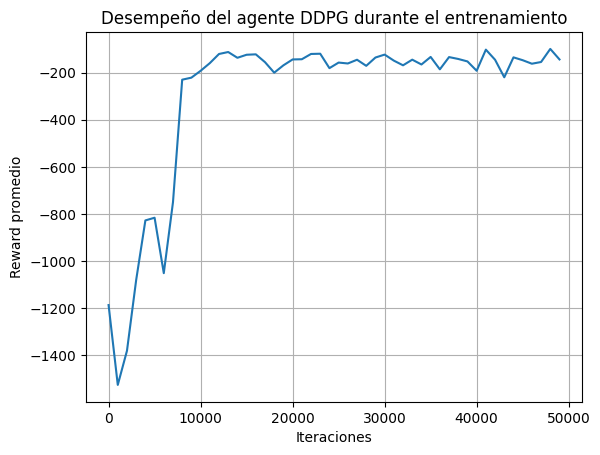

In [12]:
from tqdm import trange

# Almacenar recompensas promedio en evaluación
eval_rewards = []

# Bucle de entrenamiento
for iteration in trange(num_iterations):
    
    # 1️ Recolección de datos (1 paso por iteración)
    collect_driver.run()
    
    # 2️ Obtener un batch del dataset
    experience, _ = next(iterator)
    
    # 3️ Entrenar el agente
    train_loss = agent.train(experience)

    # 4️ Evaluación periódica
    if iteration % eval_interval == 0:
        total_return = 0.0
        for _ in range(num_eval_episodes):
            time_step = eval_env.reset()
            episode_return = 0.0

            while not time_step.is_last():
                action_step = agent.policy.action(time_step)
                time_step = eval_env.step(action_step.action)
                episode_return += time_step.reward

            total_return += episode_return

        avg_return = total_return / num_eval_episodes
        eval_rewards.append(avg_return.numpy()[0])
        print(f"\nIteración {iteration}: Reward promedio = {avg_return.numpy()[0]:.2f}")

# Gráfica de recompensa promedio por evaluación
plt.plot(np.arange(0, num_iterations, eval_interval), eval_rewards)
plt.xlabel("Iteraciones")
plt.ylabel("Reward promedio")
plt.title("Desempeño del agente DDPG durante el entrenamiento")
plt.grid()
plt.show()


# Prompt 9
Genera dos videos para el entorno Pendulum-v1 en Gymnasium, uno usando el agente DDPG entrenado y otro usando una política aleatoria (no entrenada). Usa imageio para guardar ambos como archivos .mp4 y asegúrate de que se guarden en una carpeta /kaggle/working/videos. El video debe tener 200 pasos y usarse render_mode='rgb_array'. También quiero que imprima la ruta de cada archivo generado

In [13]:
!pip install imageio[ffmpeg]

# Video con el agente entrenado (DDPG) y Video con una política aleatoria (sin entrenamiento)

In [14]:
import imageio
import os
from tf_agents.trajectories import time_step as ts

# 📁 Asegurar carpeta de salida
os.makedirs("/kaggle/working/videos", exist_ok=True)

def generate_video(policy=None, filename="pendulum.mp4", seed=0, max_steps=200):
    env = gym_vis.make("Pendulum-v1", render_mode="rgb_array")
    frames = []

    obs, _ = env.reset(seed=seed)
    for _ in range(max_steps):
        if policy is None:
            action = env.action_space.sample()
        else:
            # Crear un objeto TimeStep con la observación actual
            time_step = ts.restart(tf.convert_to_tensor([obs], dtype=tf.float32))
            action = policy.action(time_step).action.numpy()[0]
        obs, _, terminated, truncated, _ = env.step(action)
        frames.append(env.render())
        if terminated or truncated:
            break

    # Guardar video
    path = f"/kaggle/working/videos/{filename}"
    imageio.mimsave(path, frames, fps=30)
    print(f"🎥 Video guardado en: {path}")


In [15]:
# 🎬 Video con el agente entrenado
generate_video(policy=agent.policy, filename="pendulum_trained.mp4", seed=42)

# 🎬 Video con política aleatoria (sin entrenamiento)
generate_video(policy=None, filename="pendulum_random.mp4", seed=42)

🎥 Video guardado en: /kaggle/working/videos/pendulum_trained.mp4
🎥 Video guardado en: /kaggle/working/videos/pendulum_random.mp4


In [16]:
from IPython.display import HTML
import base64

def display_video(path):
    video_file = open(path, "rb").read()
    encoded = base64.b64encode(video_file).decode("ascii")
    return HTML(f"""
    <video width="480" height="360" controls>
        <source src="data:video/mp4;base64,{encoded}" type="video/mp4">
    </video>
    """)


In [17]:
# Mostrar video del agente entrenado
display_video("/kaggle/working/videos/pendulum_trained.mp4")

In [18]:
# Mostrar video del agente aleatorio
display_video("/kaggle/working/videos/pendulum_random.mp4")